In [1]:
%pip install pandas --upgrade

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install -r requirements.txt

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [4]:
def read_google_sheet(spreadsheet_id, sheet_name):
    """Read a Google Sheet tab as a DataFrame (sheet must be shared publicly)."""
    import urllib.parse
    encoded = urllib.parse.quote(sheet_name)
    url = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/gviz/tq?tqx=out:csv&sheet={encoded}"
    df = pd.read_csv(url)
    print(f"  ✓ Loaded '{sheet_name}': {df.shape[0]} rows × {df.shape[1]} cols")
    return df

Tanzania_Data = '1LRe2bjhimuwrTXU8MpmQFH02MJegNRpmwNkY9T3HGqA'

In [11]:
print("=== Loading all datasets ===\n")

# Food Expenditures (both waves)
x19 = read_google_sheet(Tanzania_Data, 'Food Expenditures (2019-20)')
x20 = read_google_sheet(Tanzania_Data, 'Food Expenditures (2020-21)')
x = pd.concat([x19, x20], ignore_index=True)

# Food Prices (both waves)
p19 = read_google_sheet(Tanzania_Data, 'Food Prices (2019-20)')
p20 = read_google_sheet(Tanzania_Data, 'Food Prices (2020-21)')
p_raw = pd.concat([p19, p20], ignore_index=True)

# Household Characteristics
hh = read_google_sheet(Tanzania_Data, 'Household Characteristics')

# Food Composition Table
fct = read_google_sheet(Tanzania_Data, 'FCT')

# RDAs (US guidelines)
rda = read_google_sheet(Tanzania_Data, "RDA's")

# THM guidelines (Tanzania)
thm = read_google_sheet(Tanzania_Data, 'THM guidelines')

# Food Categories (maps foods to THM categories)
cats = read_google_sheet(Tanzania_Data, 'Catagories')

# Region Features (rural/urban indicator per household)
region_feat = read_google_sheet(Tanzania_Data, 'Region Features')

# Subsistence farming data
farming = read_google_sheet(Tanzania_Data, 'Sub. Farming')

print("\n=== All data loaded ===")

=== Loading all datasets ===

  ✓ Loaded 'Food Expenditures (2019-20)': 15581 rows × 5 cols
  ✓ Loaded 'Food Expenditures (2020-21)': 5728 rows × 5 cols
  ✓ Loaded 'Food Prices (2019-20)': 219 rows × 5 cols
  ✓ Loaded 'Food Prices (2020-21)': 245 rows × 5 cols
  ✓ Loaded 'Household Characteristics': 4709 rows × 19 cols
  ✓ Loaded 'FCT': 67 rows × 14 cols
  ✓ Loaded 'RDA's': 13 rows × 15 cols
  ✓ Loaded 'THM guidelines': 8 rows × 15 cols
  ✓ Loaded 'Catagories': 61 rows × 3 cols
  ✓ Loaded 'Region Features': 22433 rows × 4 cols
  ✓ Loaded 'Sub. Farming': 15 rows × 5 cols

=== All data loaded ===


**Deliverable A (Demand System)**

Demand estimate succeeded
j
Beef                  0.424325
Bread                 0.133848
Citrus Fruits         1.143062
Coconuts              0.423582
Cooking Oil           0.324251
Eggs                  0.193519
Fish (fresh)          0.878667
Irish Potatoes        0.261055
Leafy Greens          0.303282
Maize (flour)         0.007951
Milk (fresh)          0.613150
Other Fruits          1.211548
Plantains             0.623253
Pulses                0.343060
Rice (husked)         0.407503
Ripe Bananas          1.124429
Salt                  0.174192
Soft drinks           0.280387
Sugar                 0.304220
Tea (dry)             0.266616
Vegetables (fresh)    0.496007
Wheat Flour           0.390250
Name: beta, dtype: float64
Median reference budget: 68723.69
Price vector (sample):
j
Beef              6658.698361
Bread             2260.791548
Citrus Fruits     1193.091267
Coconuts          1178.559854
Cooking Oil       3992.872014
Eggs               369.607843
Fish (fresh)      5229.7

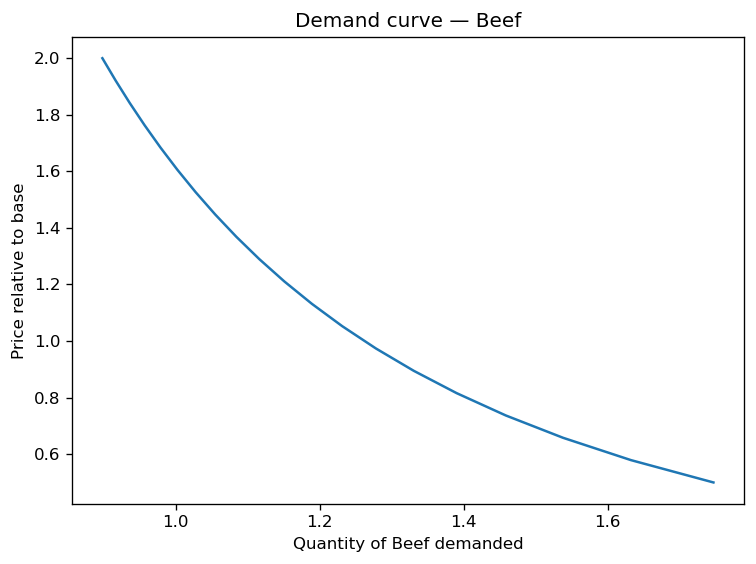

In [18]:
from cfe import Regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

food_exp = x.copy()
food_exp.columns = food_exp.columns.str.strip()
food_exp["Expenditure"] = pd.to_numeric(food_exp["Expenditure"], errors="coerce")

y = (
    food_exp
    .set_index(["i", "t", "m", "j"])["Expenditure"]
    .groupby(["i", "t", "m", "j"])
    .sum()
)
y = y.replace(0, np.nan)
y = np.log(y)

hh_data = hh.copy()
hh_data.columns = hh_data.columns.str.strip()

d = hh_data.set_index(["i", "t", "m"])
d = d.apply(pd.to_numeric, errors="coerce").fillna(0)

r = Regression(y=y, d=d)
beta = r.get_beta()
print("Demand estimate succeeded")
print(beta)

xhat = r.predicted_expenditures()
xbar = xhat.groupby(["i", "t", "m"]).sum()
xref = xbar.quantile(0.5)
print(f"Median reference budget: {xref:.2f}")

pbar = pd.Series(1.0, index=beta.index)

p_clean = p_raw.copy()
p_clean.columns = p_clean.columns.str.strip()
p_clean["Price"] = pd.to_numeric(p_clean["Price"], errors="coerce")
pbar_real = p_clean.groupby("j")["Price"].median().dropna()
pbar.update(pbar_real)
print("Price vector (sample):")
print(pbar.head(10))

foods_in_xhat = set(xhat.index.get_level_values("j"))
missing = foods_in_xhat - set(pbar.index)
if missing:
    print(f"WARNING: foods in xhat not in pbar: {missing}")

print("Available goods:", list(beta.index))
use = beta.index[0]

def my_prices(p0, p=pbar, j=use):
    p = p.copy()
    p.loc[j] = p0
    return p

scale = np.linspace(0.5, 2, 20)
quantities, prices = [], []

for s in scale:
    new_price = pbar[use] * s
    q = r.demands(xref, my_prices(new_price))
    quantities.append(q[use])
    prices.append(s)

plt.figure()
plt.plot(quantities, prices)
plt.xlabel(f"Quantity of {use} demanded")
plt.ylabel("Price relative to base")
plt.title(f"Demand curve — {use}")
plt.tight_layout()
plt.show()

**Nutrient System**

  ✓ Loaded 'FCT': 67 rows × 14 cols
  ✓ Loaded 'RDA's': 13 rows × 15 cols
FCT foods: 67,  qhat foods: 22,  overlap: 22
Predicted nutrient totals (per household per week):


i,1009-001-01,1025-001-02,1039-001-01,1078-001-01,1102-001-01,1142-001-01,1196-001-01,1213-001-01,1232-001-01,1248-001-01,...,9700-001-99,9712-001-99,9724-001-99,9736-001-99,9748-001-99,9760-001-99,9772-001-99,9784-001-99,9796-001-99,9808-001-99
t,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,...,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21,2020-21
m,Mainland Rural,Mainland Other Urban,Mainland Other Urban,Mainland Rural,Mainland Rural,Dar Es Salaam,Dar Es Salaam,Dar Es Salaam,Dar Es Salaam,Dar Es Salaam,...,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban,Mainland Other Urban
n,,,,,,,,,,,,,,,,,,,,,
Energy,1.631883e+06,694305.495856,1.480421e+06,1.804745e+06,1.148040e+06,1.065541e+06,1.690428e+06,1.475285e+06,2.139710e+06,834302.908511,...,1.331361e+06,2.125457e+06,1.333373e+06,1.289495e+06,1.282357e+06,1.733736e+06,1.333126e+06,935899.975452,1.621702e+06,1.769890e+06
Protein,5.731459e+04,23133.743355,5.318633e+04,5.466857e+04,3.132408e+04,3.529901e+04,5.970367e+04,5.333519e+04,7.037218e+04,29517.949343,...,3.862664e+04,8.657130e+04,5.210341e+04,4.115540e+04,5.185958e+04,7.339101e+04,4.115527e+04,31489.708840,6.839421e+04,5.777729e+04
Vitamin A,4.761390e+05,246132.438588,4.736513e+05,4.149329e+05,2.231908e+05,5.080376e+05,5.777548e+05,6.594980e+05,9.842048e+05,423464.015271,...,3.123427e+05,7.103436e+05,4.411222e+05,4.016482e+05,5.009189e+05,5.705851e+05,3.224397e+05,225407.223737,4.821861e+05,4.822719e+05
Vitamin D,7.499411e+03,2523.330106,7.605437e+03,5.056224e+03,1.725728e+03,4.176425e+03,8.574594e+03,9.333717e+03,8.831833e+03,3350.543864,...,2.751329e+03,1.888658e+04,9.882821e+03,7.148080e+03,8.134728e+03,1.647881e+04,4.178318e+03,2700.440748,1.405632e+04,9.064157e+03
Vitamin E,4.488836e+03,2043.842098,4.455960e+03,4.429044e+03,3.093792e+03,2.808635e+03,4.135331e+03,4.358840e+03,3.791197e+03,1985.577084,...,2.845418e+03,6.386354e+03,4.152612e+03,3.641567e+03,3.324554e+03,5.252435e+03,3.071809e+03,2064.278349,5.241813e+03,4.985445e+03


Common columns: ['Males 00-03', 'Females 00-03', 'Males 04-08', 'Females 04-08', 'Males 09-13', 'Females 09-13', 'Males 14-18', 'Females 14-18', 'Males 19-30', 'Females 19-30', 'Males 31-50', 'Females 31-50', 'Males 51-99', 'Females 51-99']
Household daily nutrient requirements:


n
Energy          9612.090680
Protein          216.458438
Vitamin A       3606.045340
Vitamin D        106.838791
Vitamin E         67.413098
Vitamin C        328.136020
Vitamin B-6        6.020151
Vitamin B-12      10.855164
Calcium         5822.670025
Magnesium       1555.667506
Iron              58.934509
Zinc              43.677582
Fiber            134.569270
dtype: float64

Nutrient adequacy ratio (1.0 = exactly meets requirement):


n
Energy           1.000000
Protein          1.149447
Vitamin A        0.979952
Vitamin D        0.793031
Vitamin E        1.356752
Vitamin C       10.335561
Vitamin B-6      4.037838
Vitamin B-12     0.757333
Calcium          0.368452
Magnesium        1.517445
Iron             0.451062
Zinc             0.280239
Fiber            1.882715
dtype: float64

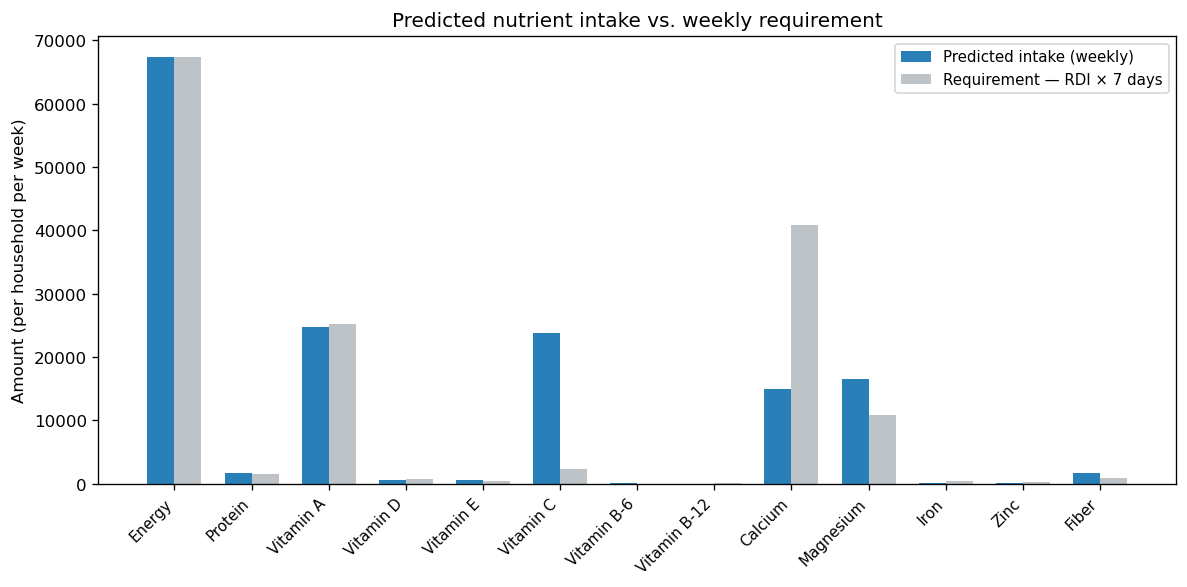

In [17]:
import pandas as pd
import numpy as np

fct = read_google_sheet(Tanzania_Data, "FCT")
fct.columns = fct.columns.str.strip()
if "j" in fct.columns:
    fct = fct.set_index("j")
fct.columns.name = "n"
fct = fct.apply(pd.to_numeric, errors="coerce")
fct = fct / 100

rdi = read_google_sheet(Tanzania_Data, "RDA's")
rdi.columns = rdi.columns.str.strip()
rdi = rdi.set_index(rdi.columns[0])
rdi.index.name = "n"
rdi.columns.name = "k"
rdi = rdi.apply(pd.to_numeric, errors="coerce")

xhat = r.predicted_expenditures()
xbar = xhat.groupby(["i", "t", "m"]).sum()
xref = xbar.quantile(0.5)
pbar = pd.Series(1.0, index=r.get_beta().index)

qhat = xhat.unstack("j") / pbar
qhat = qhat.dropna(how="all")
qhat = qhat.loc[:, qhat.count() > 0]

fct_foods  = set(fct.index)
qhat_foods = set(qhat.columns)
overlap    = fct_foods & qhat_foods
print(f"FCT foods: {len(fct_foods)},  qhat foods: {len(qhat_foods)},  overlap: {len(overlap)}")
if not overlap:
    raise ValueError("No food overlap between FCT and demand model — check food codes.")

fct_aligned, qhat_aligned = fct.align(qhat.T, axis=0, join="inner")
N = fct_aligned.T @ qhat_aligned
N = N.loc[~N.index.duplicated()]
print("Predicted nutrient totals (per household per week):")
display(N.head())

def nutrient_demand(xref, pbar, r=r, fct=fct):
    c = r.demands(xref, pbar)
    fct0, c0 = fct.align(c, axis=0, join="inner")
    N = fct0.T @ c0
    return N.loc[~N.index.duplicated()]

common_cols = rdi.columns.intersection(r.d.columns)
print(f"Common columns: {list(common_cols)}")
if len(common_cols) == 0:
    raise ValueError("No common columns between RDI and household data.")

dbar   = r.d[common_cols].mean()
hh_rdi = rdi[common_cols] @ dbar
print("Household daily nutrient requirements:")
display(hh_rdi)


def nutrient_adequacy_ratio(xref, pbar, dbar=dbar, rdi=rdi, days=7):
    common_cols = rdi.columns.intersection(dbar.index)
    hh_rdi_weekly = (
        rdi[common_cols]
        .replace("", 0)
        .apply(pd.to_numeric, errors="coerce")
        @ dbar[common_cols]
    ) * days

    intake = nutrient_demand(xref, pbar)

    
    if "Energy" in intake.index and "Energy" in hh_rdi_weekly.index:
        scale_factor = hh_rdi_weekly["Energy"] / (intake["Energy"] + 1e-9)
    else:
        scale_factor = 1.0

    intake_scaled = intake * scale_factor
    return intake_scaled / hh_rdi_weekly

nar = nutrient_adequacy_ratio(xref, pbar)
print("Nutrient adequacy ratio (1.0 = exactly meets requirement):")
display(nar)

intake   = nutrient_demand(xref, pbar)
required = hh_rdi * 7

if "Energy" in intake.index:
    scale_factor = required["Energy"] / (intake["Energy"] + 1e-9)
    intake = intake * scale_factor

nutrients  = intake.index.intersection(required.index)
intake_a   = intake.loc[nutrients]
required_a = required.loc[nutrients]

x_pos = np.arange(len(nutrients))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - width/2, intake_a.values,   width, label="Predicted intake (weekly)",   color="#2980b9", edgecolor="none")
ax.bar(x_pos + width/2, required_a.values, width, label="Requirement — RDI × 7 days",  color="#bdc3c7", edgecolor="none")
ax.set_xticks(x_pos)
ax.set_xticklabels(nutrients, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Amount (per household per week)")
ax.set_title("Predicted nutrient intake vs. weekly requirement")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()